In [16]:
import pandas as pd
import numpy as np
import os

# Check what files are in the current folder
print(os.listdir())
import pandas as pd
import numpy as np

df = pd.read_csv('delivery_data.csv')
node_metrics = pd.read_csv('node_metrics.csv')
edge_weights = pd.read_csv('edge_weight_table.csv')

print("Main data:", df.shape)
print("Node metrics:", node_metrics.shape)
print("\nNode metrics columns:", node_metrics.columns.tolist())
print("\nNode metrics sample:")
print(node_metrics.head())

['edge_weight_table.csv', 'feature_importance_delay.png', 'corridor_audit.csv', 'feature_importance.png', 'delivery_data.csv', 'task3_eta_model.ipynb', 'node_metrics.csv', 'edge_rt_aggregated.csv']
Main data: (144867, 24)
Node metrics: (1657, 10)

Node metrics columns: ['center', 'name', 'betweenness', 'in_degree', 'out_degree', 'in_degree_weighted', 'out_degree_weighted', 'clustering', 'avg_incoming_delay_factor', 'bottleneck_score']

Node metrics sample:
         center                                name  betweenness  in_degree  \
0  IND000000ACB       Gurgaon_Bilaspur_HB (Haryana)     0.233538         45   
1  IND712311AAA    Kolkata_Dankuni_HB (West Bengal)     0.073511         24   
2  IND209304AAA  Kanpur_Central_H_6 (Uttar Pradesh)     0.036469         16   
3  IND562132AAA    Bangalore_Nelmngla_H (Karnataka)     0.122355         36   
4  IND600056AAB     MAA_Poonamallee_HB (Tamil Nadu)     0.043386         18   

   out_degree  in_degree_weighted  out_degree_weighted  clusteri

In [17]:
# Merge node metrics for source hub
df = df.merge(
    node_metrics[['center', 'betweenness', 'in_degree', 'out_degree', 
                  'avg_incoming_delay_factor', 'bottleneck_score']],
    left_on='source_center',
    right_on='center',
    how='left'
).rename(columns={
    'betweenness': 'src_betweenness',
    'in_degree': 'src_in_degree',
    'out_degree': 'src_out_degree',
    'avg_incoming_delay_factor': 'src_avg_delay',
    'bottleneck_score': 'src_bottleneck_score'
}).drop(columns='center')

# Merge node metrics for destination hub
df = df.merge(
    node_metrics[['center', 'betweenness', 'in_degree', 'out_degree',
                  'avg_incoming_delay_factor', 'bottleneck_score']],
    left_on='destination_center',
    right_on='center',
    how='left'
).rename(columns={
    'betweenness': 'dst_betweenness',
    'in_degree': 'dst_in_degree',
    'out_degree': 'dst_out_degree',
    'avg_incoming_delay_factor': 'dst_avg_delay',
    'bottleneck_score': 'dst_bottleneck_score'
}).drop(columns='center')

print("New shape:", df.shape)
print("\nNew columns added:", df.columns.tolist()[-10:])

New shape: (144867, 34)

New columns added: ['src_betweenness', 'src_in_degree', 'src_out_degree', 'src_avg_delay', 'src_bottleneck_score', 'dst_betweenness', 'dst_in_degree', 'dst_out_degree', 'dst_avg_delay', 'dst_bottleneck_score']


In [18]:
# Target variable - what we want to predict
df['delay_factor'] = df['actual_time'] / df['osrm_time']

# Extract time features
df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['hour_of_day'] = df['trip_creation_time'].dt.hour
df['day_of_week'] = df['trip_creation_time'].dt.dayofweek

# Encode route type (FTL=1, Carting=0)
df['is_ftl'] = (df['route_type'] == 'FTL').astype(int)

print("Delay factor stats:")
print(df['delay_factor'].describe())
print("\nRoute type distribution:")
print(df['route_type'].value_counts())

Delay factor stats:
count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: delay_factor, dtype: float64

Route type distribution:
route_type
FTL        99660
Carting    45207
Name: count, dtype: int64


In [19]:
print(df['data'].unique())
print(df['data'].value_counts())

['training' 'test']
data
training    104858
test         40009
Name: count, dtype: int64


In [20]:
train = df[df['data'] == 'training'].copy()
test = df[df['data'] == 'test'].copy()

print("Train size:", train.shape)
print("Test size:", test.shape)

# Define features
baseline_features = [
    'osrm_time', 
    'osrm_distance', 
    'is_ftl',
    'hour_of_day', 
    'day_of_week'
]

graph_features = baseline_features + [
    'src_betweenness', 'src_in_degree', 'src_out_degree',
    'src_avg_delay', 'src_bottleneck_score',
    'dst_betweenness', 'dst_in_degree', 'dst_out_degree',
    'dst_avg_delay', 'dst_bottleneck_score'
]

target = 'actual_time'

print("\nTrain/Test split looks good!")

Train size: (104858, 38)
Test size: (40009, 38)

Train/Test split looks good!


In [21]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# Prepare data
X_train_base = train[baseline_features].fillna(0)
X_test_base = test[baseline_features].fillna(0)
y_train = train[target]
y_test = test[target]

# Train baseline model
print("Training baseline model...")
baseline_model = XGBRegressor(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
baseline_model.fit(X_train_base, y_train)

# Evaluate
y_pred_base = baseline_model.predict(X_test_base)
base_mae = mean_absolute_error(y_test, y_pred_base)
base_within_15 = np.mean(
    np.abs(y_pred_base - y_test) / y_test <= 0.15
) * 100

print(f"Baseline MAE: {base_mae:.2f} minutes")
print(f"Baseline within 15%: {base_within_15:.1f}%")

Training baseline model...
Baseline MAE: 60.00 minutes
Baseline within 15%: 42.7%


In [22]:
# Train graph-enhanced model
X_train_graph = train[graph_features].fillna(0)
X_test_graph = test[graph_features].fillna(0)

print("Training graph-enhanced model...")
graph_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
graph_model.fit(X_train_graph, y_train)

# Evaluate
y_pred_graph = graph_model.predict(X_test_graph)
graph_mae = mean_absolute_error(y_test, y_pred_graph)
graph_within_15 = np.mean(
    np.abs(y_pred_graph - y_test) / y_test <= 0.15
) * 100

print(f"Graph model MAE: {graph_mae:.2f} minutes")
print(f"Graph model within 15%: {graph_within_15:.1f}%")

# Show the improvement
print(f"\nMAE improvement: {((base_mae - graph_mae)/base_mae)*100:.1f}%")
print(f"Within-15% improvement: +{graph_within_15 - base_within_15:.1f} percentage points")


Training graph-enhanced model...
Graph model MAE: 43.65 minutes
Graph model within 15%: 54.2%

MAE improvement: 27.2%
Within-15% improvement: +11.5 percentage points


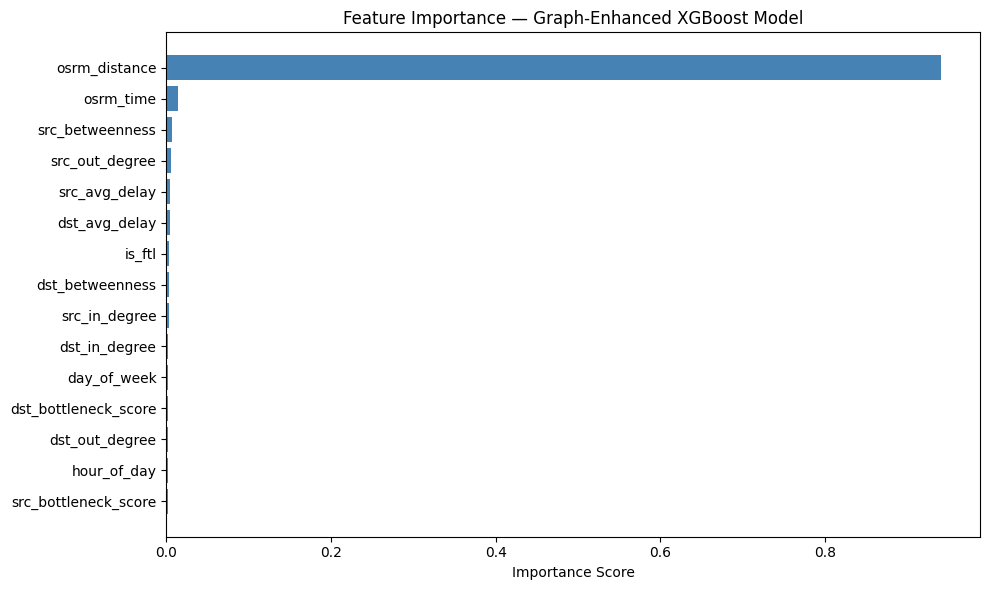

Saved: feature_importance.png


In [23]:
import matplotlib.pyplot as plt

# Get feature importances
feature_names = graph_features
importances = graph_model.feature_importances_

# Sort them
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_features[::-1], sorted_importances[::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Graph-Enhanced XGBoost Model')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("Saved: feature_importance.png")

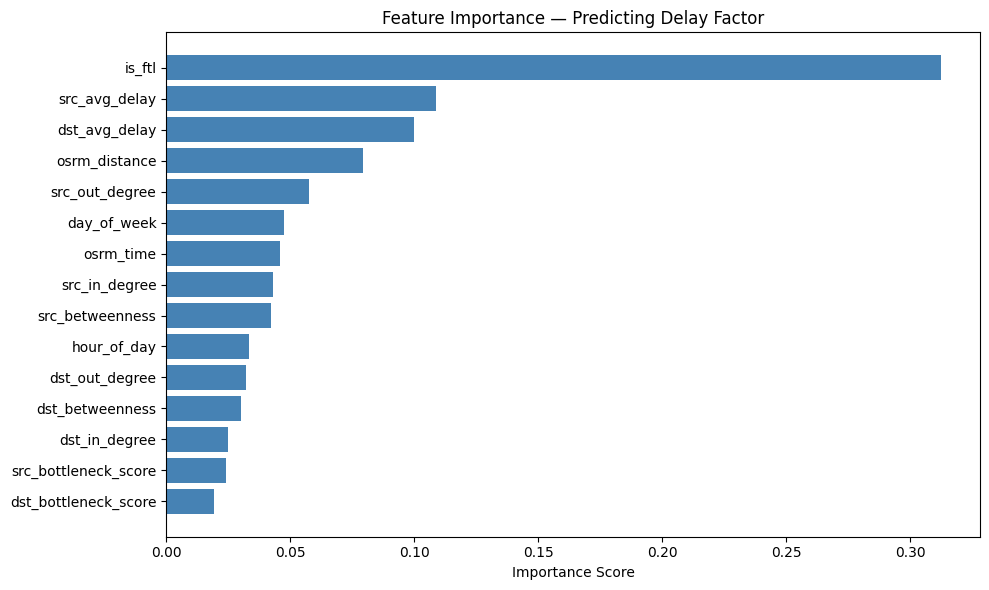

In [24]:
target2 = 'delay_factor'

X_train_graph = train[graph_features].fillna(0)
X_test_graph = test[graph_features].fillna(0)
y_train2 = train[target2]
y_test2 = test[target2]

graph_model2 = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
graph_model2.fit(X_train_graph, y_train2)

importances2 = graph_model2.feature_importances_
indices2 = np.argsort(importances2)[::-1]
sorted_features2 = [graph_features[i] for i in indices2]
sorted_importances2 = importances2[indices2]

plt.figure(figsize=(10, 6))
plt.barh(sorted_features2[::-1], sorted_importances2[::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Predicting Delay Factor')
plt.tight_layout()
plt.savefig('feature_importance_delay.png', dpi=150)
plt.show()

In [25]:
# Get predicted delay factor
y_pred_delay = graph_model2.predict(X_test_graph)

# Convert back to actual time
predicted_actual_time = y_pred_delay * test['osrm_time'].fillna(0)
real_actual_time = test['actual_time']

# Calculate MAE in minutes
mae_in_minutes = mean_absolute_error(real_actual_time, predicted_actual_time)

# Within 15%
within_15 = np.mean(
    np.abs(predicted_actual_time - real_actual_time) / real_actual_time <= 0.15
) * 100

print(f"Predicted Actual Time MAE: {mae_in_minutes:.2f} minutes")
print(f"Within 15%: {within_15:.1f}%")
print(f"\nSample predictions vs reality:")
comparison = pd.DataFrame({
    'osrm_time': test['osrm_time'].values[:10],
    'predicted_actual': predicted_actual_time.values[:10].round(1),
    'real_actual': real_actual_time.values[:10]
})
print(comparison)

Predicted Actual Time MAE: 47.41 minutes
Within 15%: 55.6%

Sample predictions vs reality:
   osrm_time  predicted_actual  real_actual
0       16.0              26.7         20.0
1       31.0              51.3         40.0
2       35.0              36.1         51.0
3       45.0              80.2         41.0
4       57.0             111.1         61.0
5       26.0              47.2         36.0
6       46.0              86.7         93.0
7       72.0             136.1        129.0
8       97.0             185.6        171.0
9      116.0             222.6        215.0


In [26]:
pip install node2vec

Note: you may need to restart the kernel to use updated packages.


In [27]:
import networkx as nx
from node2vec import Node2Vec

print("Building graph for node2vec...")

# Build directed graph from edge weights
G = nx.DiGraph()
for _, row in edge_weights.iterrows():
    G.add_edge(
        str(row['source_center']),
        str(row['destination_center']),
        weight=float(row['median_factor'])
    )

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Run node2vec
print("Running node2vec random walks (this takes 2-3 minutes)...")
node2vec = Node2Vec(
    G,
    dimensions=32,
    walk_length=30,
    num_walks=100,
    workers=1,
    quiet=True
)
model_n2v = node2vec.fit(window=10, min_count=1)

print("Done! Embedding shape per node: 32 dimensions")

Building graph for node2vec...
Graph: 1639 nodes, 2750 edges
Running node2vec random walks (this takes 2-3 minutes)...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Done! Embedding shape per node: 32 dimensions


In [28]:
# Convert node2vec embeddings to dataframe
emb_rows = []
for node in G.nodes():
    if str(node) in model_n2v.wv:
        vec = model_n2v.wv[str(node)]
        emb_rows.append([str(node)] + list(vec))

emb_cols = ['center'] + [f'n2v_{i}' for i in range(32)]
emb_df = pd.DataFrame(emb_rows, columns=emb_cols)

print("Embeddings dataframe shape:", emb_df.shape)
print("Sample:")
print(emb_df.head(3))

# Merge embeddings for source hub
df_n2v = df.merge(
    emb_df.rename(columns={'center': 'source_center'}).add_prefix('src_').rename(columns={'src_source_center': 'source_center'}),
    on='source_center', how='left'
)

# Merge embeddings for destination hub
df_n2v = df_n2v.merge(
    emb_df.rename(columns={'center': 'destination_center'}).add_prefix('dst_').rename(columns={'dst_destination_center': 'destination_center'}),
    on='destination_center', how='left'
)

n2v_src_cols = [f'src_n2v_{i}' for i in range(32)]
n2v_dst_cols = [f'dst_n2v_{i}' for i in range(32)]

print(f"\nNew shape: {df_n2v.shape}")
print(f"Added {len(n2v_src_cols + n2v_dst_cols)} node2vec features")

Embeddings dataframe shape: (1639, 33)
Sample:
         center     n2v_0     n2v_1     n2v_2     n2v_3     n2v_4     n2v_5  \
0  IND000000AAL -0.703957 -0.273749  0.023962  0.222318 -0.004750 -0.771781   
1  IND411033AAA -0.718338 -0.211128 -0.111319  0.129725  0.011148 -0.727739   
2  IND000000AAQ  0.459565  0.691114 -0.558004  0.239354  0.302415 -0.558140   

      n2v_6     n2v_7     n2v_8  ...    n2v_22    n2v_23    n2v_24    n2v_25  \
0 -0.957116  0.104396 -0.515602  ... -0.063550 -0.091054  0.469818 -0.416204   
1 -0.919211  0.196477 -0.425028  ... -0.097230 -0.045171  0.391220 -0.368341   
2  0.702962  0.713470 -1.160351  ...  0.095203 -0.765831 -0.342739 -0.549408   

     n2v_26    n2v_27    n2v_28    n2v_29    n2v_30    n2v_31  
0 -0.510274  0.220372 -0.040482  0.813190 -0.298260 -0.247471  
1 -0.593104  0.229984 -0.102693  0.686045 -0.261541 -0.185485  
2 -0.335804  0.335294 -0.369829  0.704945  0.224522 -0.994409  

[3 rows x 33 columns]

New shape: (144867, 102)
Added 64 n

In [29]:
# node2vec features + original graph features
n2v_features = graph_features + n2v_src_cols + n2v_dst_cols

# Split train/test
train_n2v = df_n2v[df_n2v['data'] == 'training'].copy()
test_n2v = df_n2v[df_n2v['data'] == 'test'].copy()

X_train_n2v = train_n2v[n2v_features].fillna(0)
X_test_n2v = test_n2v[n2v_features].fillna(0)
y_train_n2v = train_n2v['actual_time']
y_test_n2v = test_n2v['actual_time']

# Train node2vec enhanced model
print("Training node2vec enhanced model...")
n2v_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
n2v_model.fit(X_train_n2v, y_train_n2v)

# Evaluate
y_pred_n2v = n2v_model.predict(X_test_n2v)
n2v_mae = mean_absolute_error(y_test_n2v, y_pred_n2v)
valid_mask = y_test_n2v > 0
n2v_within_15 = np.mean(
    np.abs(y_pred_n2v[valid_mask] - y_test_n2v[valid_mask]) / y_test_n2v[valid_mask] <= 0.15
) * 100

# Final comparison
print("\n=== FINAL MODEL COMPARISON ===")
print(f"Baseline XGBoost       — MAE: {base_mae:.2f} mins | Within 15%: {base_within_15:.1f}%")
print(f"Graph-Enhanced XGBoost — MAE: {graph_mae:.2f} mins | Within 15%: {graph_within_15:.1f}%")
print(f"node2vec Enhanced      — MAE: {n2v_mae:.2f} mins | Within 15%: {n2v_within_15:.1f}%")
print(f"\nTotal improvement over baseline: {((base_mae - n2v_mae)/base_mae)*100:.1f}% MAE reduction")

Training node2vec enhanced model...

=== FINAL MODEL COMPARISON ===
Baseline XGBoost       — MAE: 60.00 mins | Within 15%: 42.7%
Graph-Enhanced XGBoost — MAE: 43.65 mins | Within 15%: 54.2%
node2vec Enhanced      — MAE: 42.64 mins | Within 15%: 54.3%

Total improvement over baseline: 28.9% MAE reduction
